# 第7回：カルマンフィルタ（KF）と拡張カルマンフィルタ（EKF）による移動ロボット位置推定

このノートでは、カルマンフィルタ（KF）と拡張カルマンフィルタ（EKF）の基本を学び、差動二輪移動ロボットの位置推定を Python でシミュレーションします。

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir(f'/content/drive/MyDrive/Colab Notebooks/システム最適化特論/Lecture7')

Mounted at /content/drive


## 学習目標

- KF / EKF の数式とアルゴリズムの流れを理解する
- 差動二輪ロボットの運動モデル（オドメトリ）を理解する
- AprilTag のようなランドマーク観測を用いた位置補正を理解する
- Python / Colab 上で EKF ローカリゼーションを実装し、真値・オドメトリ・EKF の軌跡を可視化する

---

## 0. 準備（ライブラリのインポート）

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# グラフをノート内に表示
%matplotlib inline

# 乱数シード（毎回同じ結果が出るように）
np.random.seed(0)


# 1. Kalman Filter (KF)
KF の更新は「予測」と「観測」の誤差を両方まとめて最小二乗法で最適化することで得られる

## 1.1 カルマンフィルタ（KF）の状態方程式

カルマンフィルタは **線形ガウスシステム** を前提とする

### 状態遷移モデル（State Transition Model）

$$
\boldsymbol{x}_{k} = \boldsymbol{A} \boldsymbol{x}_{k-1} + \boldsymbol{B} \boldsymbol{u}_{k} + \boldsymbol{w}_{k}
$$
- $\boldsymbol{x}_k$：時刻 \(k\) の状態ベクトル  
- $\boldsymbol{A} $：状態遷移行列   （移動ロボットの場合は単位行列）
- $\boldsymbol{u}_k$：時刻 \(k\) の入力（制御入力）  
- $\boldsymbol{B}$：入力行列  
- $\boldsymbol{w}_k$：プロセスノイズ  
  $$
  \boldsymbol{w}_k \sim \mathcal{N}(0,\, Q)
  $$  
  （平均 0、共分散 \(Q\) のガウスノイズ）

### 観測モデル（Observation Model）

$$
\boldsymbol{z}_k = \boldsymbol{C} \boldsymbol{x}_k + \boldsymbol{v}_k
$$
- $\boldsymbol{z}_k$：時刻 \(k\) の観測ベクトル  
- $\boldsymbol{C}$：観測行列  
- $\boldsymbol{v}_k$：観測ノイズ  
  $$
  v_k \sim \mathcal{N}(0,\, R)
  $$  
  （平均 0、共分散 \(R\) のガウスノイズ）

## KF の予測ステップ（Predict Step）
カルマンフィルタの予測ステップは、**状態（平均値）** と **誤差共分散（不確かさ）** を別々に更新する。


---

### 🔷 1. 状態の予測（state prediction）
$$
\hat{\boldsymbol{x}}_{k|k-1}
=
\boldsymbol{A}\,\hat{\boldsymbol{x}}_{k-1|k-1}
+
\boldsymbol{B}\,\boldsymbol{u}_k
$$

- $\hat{\boldsymbol{x}}_{k|k-1}$：予測された状態（prior）  
- $\hat{\boldsymbol{x}}_{k-1|k-1}$：前回の推定値  
- $\boldsymbol{A}$：状態遷移行列  
- $\boldsymbol{B}$：入力行列  
- $\boldsymbol{u}_k$：入力（制御入力）  

👉 **この式にはノイズ共分散 $\boldsymbol{Q}$ は登場しない**  （モデルに従って、平均状態がどこへ移動するかだけが決まる）

---

### 🔷 2. 共分散の予測（covariance prediction）

$$
\boldsymbol{P}_{k|k-1}
=
\boldsymbol{A}\,\boldsymbol{P}_{k-1|k-1}\,\boldsymbol{A}^\top
+
\boldsymbol{Q}
$$

- $\boldsymbol{P}_{k|k-1}$：予測誤差共分散（不確かさの広がり）  
- $\boldsymbol{P}_{k-1|k-1}$：前回の誤差共分散  
- $\boldsymbol{Q}$：プロセスノイズの共分散  （路面とのスリップなどに起因。固定値でもよい。）

 **この式には入力 $\boldsymbol{u}_k$ は登場しない。**  $(\boldsymbol{u}_k$ は状態の平均だけを動かし、不確かさには直接影響しない）
---


## KF の更新ステップ（Update Step）

カルマンフィルタの更新ステップ（観測更新）は、**予測（prior）** と **観測** を組み合わせて状態を改善する処理です。

### 🔷 1. イノベーション（観測残差）

観測と予測のずれを表す量：

$$
\boldsymbol{y}_k
=
\boldsymbol{z}_k
-
\boldsymbol{C}\,\hat{\boldsymbol{x}}_{k|k-1}
$$

- $\boldsymbol{y}_k$：イノベーション（観測残差）  
- $\boldsymbol{z}_k$：観測  （例えば、ランドマークのカメラでの見え方など）
- $\boldsymbol{C}$：観測行列  （例えば、ロボット位置とランドマークの座標位置の情報からランドマークがらカメラにどう映るかを計算する行列）
- $\hat{\boldsymbol{x}}_{k|k-1}$：予測状態  

---

### 🔷 2. イノベーション共分散

$$
\boldsymbol{S}_k
=
\boldsymbol{C}\,\boldsymbol{P}_{k|k-1}\,\boldsymbol{C}^\top
+
\boldsymbol{R}
$$

- $\boldsymbol{R}$：観測ノイズ共分散  （センサ特性から求まる。経験的な固定値でもよい）

---

### 🔷 3. カルマンゲイン

観測をどれだけ信じるかを決める重み：

$$
\boldsymbol{K}_k
=
\boldsymbol{P}_{k|k-1}\,\boldsymbol{C}^\top
\boldsymbol{S}_k^{-1}
$$

これはカルマンフィルタの目的関数の解析解として現れる
#### 目的関数:
$$
f(\boldsymbol{x})=(\boldsymbol{z}_k - \boldsymbol{C}\boldsymbol{x})^\top \boldsymbol{R}^{-1}(\boldsymbol{z}_k - \boldsymbol{C}\boldsymbol{c})+(\boldsymbol{x} - \hat{\boldsymbol{x}}_{k|k-1})^\top \boldsymbol{P}_{k|k-1}^{-1}(x - \hat{\boldsymbol{x}}_{k|k-1})
$$
を微分して、$ \frac{\partial{f}}{\partial x} = 0 $
を解くと、解析解としてカルマンゲインが求まる。
カルマンゲインは「予測誤差と観測誤差の最小二乗解」そのもの。

---

### 🔷 4. 状態の更新（posterior estimate）

$$
\hat{\boldsymbol{x}}_{k|k}
=
\hat{\boldsymbol{x}}_{k|k-1}
+
\boldsymbol{K}_k \boldsymbol{y}_k
$$

- 予測 $\hat{\boldsymbol{x}}_{k|k-1}$ に観測による補正 $\boldsymbol{K}_k\boldsymbol{y}_k$ を足す。

---

### 🔷 5. 共分散の更新（不確かさの縮小）

$$
\boldsymbol{P}_{k|k}
=
(\boldsymbol{I}
-
\boldsymbol{K}_k \boldsymbol{C})
\boldsymbol{P}_{k|k-1}
$$

- 観測を使うと、不確かさ（共分散）は小さくなる。  
  （$\boldsymbol{P}_{k|k} \le \boldsymbol{P}_{k|k-1}$ が成り立つ）

---

## 1.2 ウォームアップ：1次元のカルマンフィルタ（KF）

まずは **1次元の位置推定** のシンプルな例で KF の動きを体験します。

モデル：
- 状態 : $x_k$ （位置）
- 制御入力 : なし
- 状態方程式 : $x_{k+1} = x_k + w_k$ （ゆっくりランダムに動く）
- 観測 : $z_k = x_k + v_k$
- $w_k \sim \mathcal{N}(0, Q)$, $v_k \sim \mathcal{N}(0, R)$

カルマンフィルタの基本式：
- 予測 :
  - $\hat{x}_{k|k-1} = \hat{x}_{k-1}$
  - $P_{k|k-1} = P_{k-1} + Q$
- 更新 :
  - カルマンゲイン $K_k = \dfrac{P_{k|k-1}}{P_{k|k-1} + R}$
  - 状態更新 $\hat{x}_k = \hat{x}_{k|k-1} + K_k (z_k - \hat{x}_{k|k-1})$
  - 共分散更新 $P_k = (1 - K_k) P_{k|k-1}$

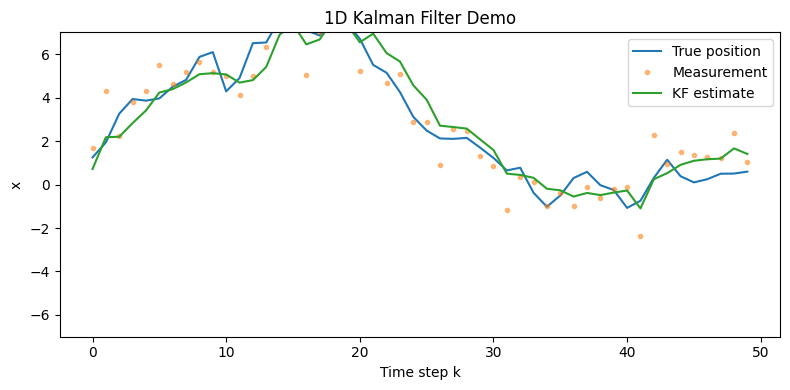

In [4]:
# 1次元のKFデモ

T = 50             # 時刻ステップ数
Q = 0.5           # プロセスノイズ分散
R = 1.1            # 観測ノイズ分散

x_true = 0.0       # 真値の初期位置
x_hat  = 0.0       # 推定値の初期位置
P = 1.0            # 共分散の初期値

true_hist = []
meas_hist = []
est_hist  = []
Phist     = []

for k in range(T):
    # 真値の遷移
    w = np.random.randn() * np.sqrt(Q)
    x_true = x_true + w

    # 観測
    v = np.random.randn() * np.sqrt(R)
    z = x_true + v

    # --- KF 予測 ---
    x_pred = x_hat
    P_pred = P + Q

    # --- KF 更新 ---
    K = P_pred / (P_pred + R)
    K=K*0.7400005   #ゲインの更新
    x_hat = x_pred + K * (z - x_pred)
    P = (1 - K) * P_pred

    true_hist.append(x_true)
    meas_hist.append(z)
    est_hist.append(x_hat)
    Phist.append(P)

true_hist = np.array(true_hist)
meas_hist = np.array(meas_hist)
est_hist  = np.array(est_hist)
Phist     = np.array(Phist)

plt.figure(figsize=(8,4))
plt.plot(true_hist, label="True position")
plt.plot(meas_hist, '.', alpha=0.5, label="Measurement")
plt.plot(est_hist, label="KF estimate")
plt.xlabel("Time step k")
plt.ylabel("x")
plt.legend()
plt.title("1D Kalman Filter Demo")
plt.tight_layout()
plt.ylim(-7,7)
plt.show()


**演習 1（任意）**
- Q, R の値を変えて、推定結果がどのように変化するか観察してみてください。
  - Q を大きくすると？ R を大きくすると？

---

# 2. 差動二輪ロボットの運動モデル（オドメトリ）

次に、2輪差動駆動ロボットを考えます。

状態ベクトル：
\begin{equation}
\boldsymbol{x} = [x,\ y,\ \theta]^T
\end{equation}

- $x, y$ : ロボットの位置
- $\theta$ : ロボットの向き（姿勢角）

制御入力：
\begin{equation}
\boldsymbol{u} = [v,\ \omega]^T
\end{equation}
- $v$ : 並進速度
- $\omega$ : 角速度

離散時間の運動モデル（時間刻み $\Delta t$）：
\begin{align}
x_{k+1} &= x_k + v \cos\theta_k \Delta t,\\
y_{k+1} &= y_k + v \sin\theta_k \Delta t,\\
\theta_{k+1} &= \theta_k + \omega \Delta t.
\end{align}

これは **非線形** なので、そのままでは通常の KF は使えません（→ EKF が必要）。

In [5]:
def motion_model(x, u, dt):
    """差動二輪ロボットの非線形運動モデル

    x : 状態 (3, ) = [x, y, theta]
    u : 制御入力 (2, ) = [v, omega]
    dt: サンプリング時間
    """
    v, w = u
    theta = x[2]
    x_next = np.array([
        x[0] + v * np.cos(theta) * dt,
        x[1] + v * np.sin(theta) * dt,
        x[2] + w * dt
    ])
    # theta を -pi〜pi の範囲に正規化
    x_next[2] = (x_next[2] + np.pi) % (2*np.pi) - np.pi
    return x_next


動作確認をしてみます。

In [ ]:
# 動作確認
x = np.array([0.0, 0.0, 0.0])
u = np.array([0.5, 0.3])  # v=0.5 m/s, omega=0.3 rad/s
dt = 0.1

for k in range(5):
    x = motion_model(x, u, dt)
    print(f"k={k+1}: x={x}")


k=1: x=[0.05 0.   0.03]
k=2: x=[0.0999775  0.00149978 0.06      ]
k=3: x=[0.14988753 0.00449798 0.09      ]
k=4: x=[0.19968517 0.0089919  0.12      ]
k=5: x=[0.2493256  0.01497751 0.15      ]


---
# 3. AprilTag 的なランドマーク観測モデル

固定された AprilTag（ランドマーク）が 1 つ、位置 $\boldsymbol{p}_t = [x_t, y_t]^T$ に置かれているとします。

ロボットから見た観測量：
- 距離 $r$
- 方位角 $b$（ロボットの向きから見た角度）

モデル：
\begin{align}
r &= \sqrt{(x_t - x)^2 + (y_t - y)^2},\\
b &= \mathrm{atan2}(y_t - y, x_t - x) - \theta.
\end{align}

観測ベクトル：
\begin{equation}
\boldsymbol{z} = [r,\ b]^T.
\end{equation}

こちらも非線形です。

In [ ]:
# AprilTag (ランドマーク) の位置
tag_pos = np.array([2.0, 2.0])  # (x_t, y_t)

def observe(x, tag_pos):
    """ロボット状態 x とタグ位置 tag_pos から、距離 r と方位角 b を返す

    x : [x, y, theta]
    tag_pos : [x_t, y_t]
    """
    dx = tag_pos[0] - x[0]
    dy = tag_pos[1] - x[1]
    r = np.sqrt(dx**2 + dy**2)
    b = np.arctan2(dy, dx) - x[2]
    # 角度を -pi〜pi に正規化
    b = (b + np.pi) % (2*np.pi) - np.pi
    return np.array([r, b])

# 動作確認
x_test = np.array([0.0, 0.0, 0.0])
z_test = observe(x_test, tag_pos)
print("z =", z_test, "(r, b)")


z = [2.82842712 0.78539816] (r, b)


**演習 2（任意）**
- ロボットの位置を変えて、観測 $z=[r,b]^T$ がどのように変化するか試してみてください。

---

# 4. EKF のためのヤコビ行列（線形化）

拡張カルマンフィルタ（EKF）では、非線形な運動モデル・観測モデルを、
現在の推定点のまわりで一次近似（線形化）します。

運動モデル： $\boldsymbol{x}_{k+1} = f(\boldsymbol{x}_k, \boldsymbol{u}_k)$

ヤコビ行列（状態に関する偏微分）：
\begin{equation}
F_k = \frac{\partial f}{\partial \boldsymbol{x}} \Bigg|_{\boldsymbol{x}=\hat{\boldsymbol{x}}_k}
\end{equation}

観測モデル： $\boldsymbol{z}_k = h(\boldsymbol{x}_k)$ に対して
\begin{equation}
H_k = \frac{\partial h}{\partial \boldsymbol{x}} \Bigg|_{\boldsymbol{x}=\hat{\boldsymbol{x}}_{k|k-1}}
\end{equation}

これらを用いて、KF と同じ形の式で共分散やカルマンゲインを更新します。

In [ ]:
def jacobian_motion(x, u, dt):
    """運動モデルのヤコビ行列 F = df/dx

    x : [x, y, theta]
    u : [v, omega]
    """
    v, w = u
    theta = x[2]
    F = np.array([
        [1.0, 0.0, -v * np.sin(theta) * dt],
        [0.0, 1.0,  v * np.cos(theta) * dt],
        [0.0, 0.0, 1.0]
    ])
    return F

def jacobian_observe(x, tag_pos):
    """観測モデルのヤコビ行列 C = dc/dx   #KFの説明のところでは、観測モデルのヤコビ行列は C としていた

    x : [x, y, theta]
    tag_pos : [x_t, y_t]
    """
    dx = tag_pos[0] - x[0]
    dy = tag_pos[1] - x[1]
    q = dx**2 + dy**2
    r = np.sqrt(q)

    # r = sqrt(q)
    # b = atan2(dy, dx) - theta
    C = np.array([
        [-dx/r, -dy/r,    0.0],
        [ dy/q, -dx/q, -1.0]
    ])
    return C


---
# 5. EKF のアルゴリズム

状態推定値：$\hat{\boldsymbol{x}}_k$、共分散：$P_k$ とします。

### 5.1 予測ステップ（Predict）
\begin{align}
\hat{\boldsymbol{x}}_{k|k-1} &= f(\hat{\boldsymbol{x}}_{k-1}, \boldsymbol{u}_k),\\
P_{k|k-1} &= F_k P_{k-1} F_k^T + Q.
\end{align}

### 5.2 更新ステップ（Update）
\begin{align}
\boldsymbol{z}_k &= h(\boldsymbol{x}_k) + \boldsymbol{v}_k,\\
\boldsymbol{y}_k &= \boldsymbol{z}_k - h(\hat{\boldsymbol{x}}_{k|k-1}) \quad (\text{イノベーション}),\\
S_k &= H_k P_{k|k-1} H_k^T + R,\\
K_k &= P_{k|k-1} H_k^T S_k^{-1},\\
\hat{\boldsymbol{x}}_k &= \hat{\boldsymbol{x}}_{k|k-1} + K_k \boldsymbol{y}_k,\\
P_k &= (I - K_k H_k) P_{k|k-1}.
\end{align}

これをコードにします。

In [ ]:
def ekf_step(x, P, u, z, Q, R, dt, tag_pos):
    """EKF 1ステップ

    x, P : 直前時刻の推定状態・共分散
    u    : 制御入力 [v, omega]
    z    : 観測 [r, b]
    Q, R : プロセス・観測ノイズ共分散
    dt   : サンプリング時間
    tag_pos: タグ位置
    """
    # 予測
    x_pred = motion_model(x, u, dt)
    F = jacobian_motion(x, u, dt)
    P_pred = F @ P @ F.T + Q

    # 観測更新
    H = jacobian_observe(x_pred, tag_pos)
    z_pred = observe(x_pred, tag_pos)

    # 角度差を -pi〜pi に正規化
    y = z - z_pred
    y[1] = (y[1] + np.pi) % (2*np.pi) - np.pi

    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x_new = x_pred + K @ y
    P_new = (np.eye(3) - K @ H) @ P_pred

    # theta を -pi〜pi に正規化
    x_new[2] = (x_new[2] + np.pi) % (2*np.pi) - np.pi

    return x_new, P_new


---
## 6. シミュレーション設定

- 真のロボットは、あるパターンで走行する
- オドメトリ（制御入力）はノイズを含む
- 一定ステップごとに AprilTag を観測（距離＋角度にノイズ）
- EKF を用いて、状態推定を行う

パラメータを設定して、シミュレーションを実行します。

In [ ]:
# シミュレーションパラメータ
T = 200           # ステップ数
dt = 0.1          # サンプリング時間 [s]

# プロセスノイズ共分散行列 Q (x, y, theta)
#Q = np.diag([0.0, 0.00, 0])
Q = np.diag([0.01, 0.01, np.deg2rad(1.0)**2])

# 観測ノイズ共分散行列 R (range, bearing)
R = np.diag([0.1**2, np.deg2rad(3.0)**2])

# 真値・オドメトリ・EKF の状態
x_true = np.array([0.0, 0.0, 0.0])
x_odo  = np.array([0.0, 0.0, 0.0])
x_ekf  = np.array([0.0, 0.0, 0.0])
P_ekf  = np.eye(3) * 0.5

true_hist = []
odo_hist  = []
ekf_hist  = []

# u(t) を簡単なパターンで与える関数
def control_input(k):
    # 途中で曲がるような軌跡
    if k < 60:
        v = 0.3
        w = 0.0
    elif k < 120:
        v = 0.3
        w = 0.4
    else:
        v = 0.3
        w = -0.4
    return np.array([v, w])

for k in range(T):
    # 真の制御入力
    u = control_input(k)

    # 真値の更新（ノイズなし）
    x_true = motion_model(x_true, u, dt)

    # オドメトリ用の制御入力（ノイズ付き）
    u_odo = u + np.array([
        np.random.randn()*0.02,
        np.random.randn()*np.deg2rad(2.0)
    ])

    # オドメトリによる状態更新
    x_odo = motion_model(x_odo, u_odo, dt)

    # EKF 予測（観測がなくても予測だけは進めておく）
    # → 観測が入るタイミングで ekf_step で更新

    # 観測（一定ステップごとに実施）
    if k % 5 == 0:
        # 真値から理想的な観測を計算し、ノイズを足す
        z_true = observe(x_true, tag_pos)
        z = z_true + np.array([
            np.random.randn()*0.1,              # range ノイズ
            np.random.randn()*np.deg2rad(3.0)  # bearing ノイズ
        ])

        # EKF 更新
        x_ekf, P_ekf = ekf_step(x_ekf, P_ekf, u_odo, z, Q, R, dt, tag_pos)
    else:
        # 観測がないときは予測のみ
        F = jacobian_motion(x_ekf, u_odo, dt)
        x_ekf = motion_model(x_ekf, u_odo, dt)
        P_ekf = F @ P_ekf @ F.T + Q

    true_hist.append(x_true.copy())
    odo_hist.append(x_odo.copy())
    ekf_hist.append(x_ekf.copy())

true_hist = np.array(true_hist)
odo_hist  = np.array(odo_hist)
ekf_hist  = np.array(ekf_hist)


---
## 7. 結果の可視化

- 真の軌跡
- オドメトリのみの軌跡
- EKF による推定軌跡
- ランドマーク（AprilTag）の位置

をプロットします。

In [1]:
plt.figure(figsize=(6,6))
plt.plot(true_hist[:,0], true_hist[:,1], label="True")
plt.plot(odo_hist[:,0],  odo_hist[:,1],  label="Odometry")
plt.plot(ekf_hist[:,0],  ekf_hist[:,1],  label="EKF")

plt.scatter(tag_pos[0], tag_pos[1], marker="*", s=200, label="AprilTag (landmark)")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("EKF Localization with Single Landmark")
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

オドメトリのみの軌跡（Odometry）は、時間とともに **真値からずれていく** はずです。
一方、EKF の軌跡（EKF）は、ランドマーク観測が入るたびに真値に引き寄せられます。

---

## 8. 演習課題（発展）最終レポート

> 引用を追加



次のような改良・実験をして、EKF の挙動を観察してみてください。

1. **観測ノイズ R を変えてみる**
   - R を小さくすると → 観測をどれくらい強く信じるようになりますか？
   - R を大きくすると → オドメトリ重視になりますか？

2. **プロセスノイズ Q を変えてみる**
   - Q を大きくすると、どう変わるでしょうか？

3. **観測間隔を変えてみる**
   - 観測の頻度を変更し、どのように変わるか確認する。

4. **制御入力パターンの変更**
   - `control_input(k)` を変更し、8の字軌跡や円軌跡を試してみてください。

5. **ランドマークを複数個に増やす（発展）**
   - tag_pos をリストにして、観測モデル・ヤコビ行列を拡張してみてください。

---